# Imports

In [1]:
import os

os.environ["KERAS_BACKEND"] = "torch"
import keras
import torch

In [2]:
import datasets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn.metrics
import sklearn.model_selection
import transformers


c:\Users\Yanovich\Documents\Projects\Cats\neural\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
print('CUDA:', torch.version.cuda)
print('GPU:', torch.cuda.is_available())

CUDA: 12.8
GPU: True


# Dataset

Load the dataset (we will be using [go_emotions](https://huggingface.co/datasets/google-research-datasets/go_emotions)). Pretokenize data or make a loader that tokenizes the sentenses as you iterate through the dataset. Implement two datasets: variable and fixed sentence length (in tokens). Don't forget to split the dataset into train and test subsets

In [4]:
dataset = datasets.load_dataset('google-research-datasets/go_emotions', name='raw', split='train')

In [5]:
emotions = [
    'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity',
    'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear',
    'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]

In [6]:
tokenizer = transformers.AutoTokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token

In [7]:
dataset

Dataset({
    features: ['text', 'id', 'author', 'subreddit', 'link_id', 'parent_id', 'created_utc', 'rater_id', 'example_very_unclear', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral'],
    num_rows: 211225
})

In [8]:
df: pd.DataFrame = dataset.to_pandas()

In [9]:
import seaborn as sns

<Axes: xlabel='None'>

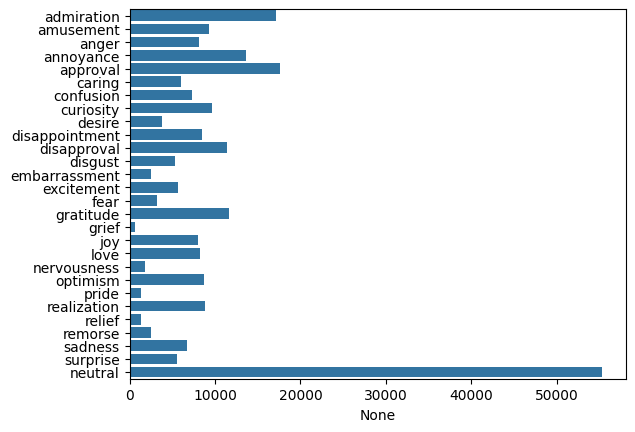

In [10]:
sns.barplot(x=df[emotions].sum(), y=emotions, orient="h")

In [11]:
text_tokens = [tokenizer.encode(text) for text in df["text"]]

Token indices sequence length is longer than the specified maximum sequence length for this model (1435 > 1024). Running this sequence through the model will result in indexing errors


In [12]:
len_tokens = [len(tokens) for tokens in text_tokens]

<Axes: ylabel='Count'>

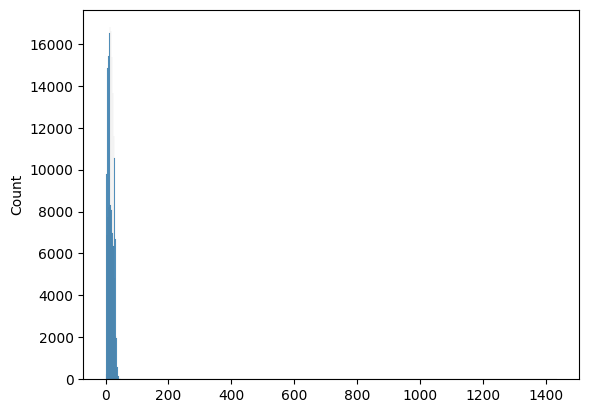

In [13]:
sns.histplot(len_tokens)

<Axes: ylabel='Count'>

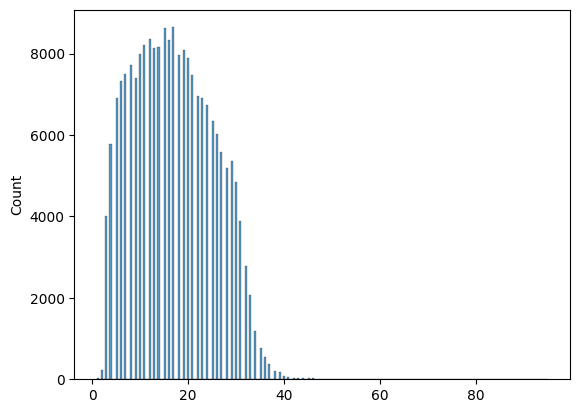

In [14]:
sns.histplot([x for x in len_tokens if x < 100])

In [15]:
np.percentile(len_tokens, 95)

np.float64(31.0)

In [16]:
text_tokens_pad = keras.utils.pad_sequences(text_tokens, maxlen=31, padding='post', truncating='post', value=tokenizer.eos_token_id)

In [17]:
labels = df[emotions].to_numpy()

In [18]:
labels

array([[0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 1],
       ...,
       [1, 0, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(211225, 28), dtype=int32)

<Axes: ylabel='Count'>

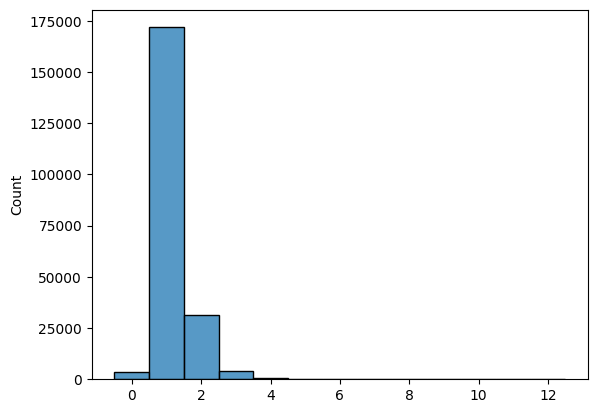

In [19]:
sns.histplot(labels.sum(axis=1), discrete=True)

In [20]:
len(df["text"].unique())

57732

In [21]:
agg_rules = {e: "max" for e in emotions}
grouped = df.groupby("id").agg({"text": "first", **agg_rules}).reset_index()

<Axes: ylabel='Count'>

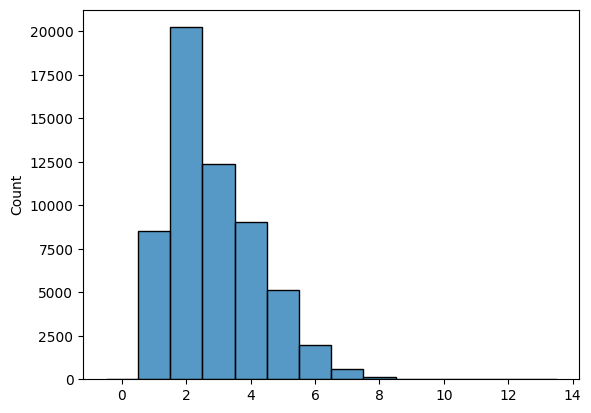

In [22]:
sns.histplot(grouped[emotions].to_numpy().sum(axis=1), discrete=True)

<Axes: xlabel='None'>

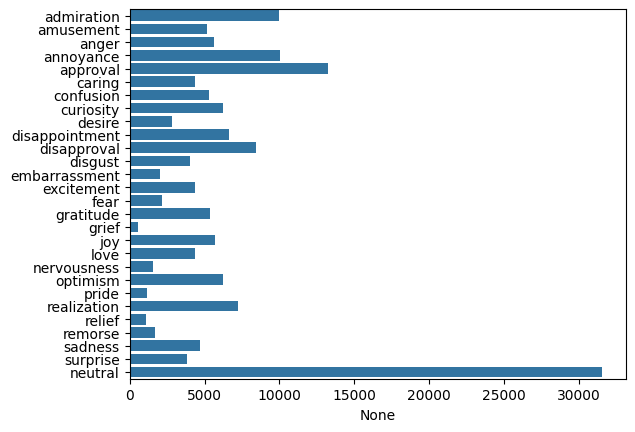

In [23]:
sns.barplot(x=grouped[emotions].sum(), y=emotions, orient="h")

In [24]:
class GoEmotionsDataset(keras.utils.PyDataset):
    def __init__(
        self,
        x: pd.Series,
        y: np.ndarray,
        tokenizer,
        max_seq_length: int,
        fixed_seq_length: bool,
        batch_size: int = 128,
        shuffle: bool = True,
        rng: np.random.Generator | None = None,
        **kwargs,
    ):
        super().__init__(**kwargs)
        if rng is None:
            rng = np.random.default_rng()

        self.rng = rng
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.max_seq_length = max_seq_length
        self.fixed_seq_length = fixed_seq_length
        self.tokenizer = tokenizer

        full_text_tokens = [tokenizer.encode(text) for text in x]
        lengths = np.array([len(t) for t in full_text_tokens])
        mask = lengths < max_seq_length

        self.raw_text_tokens = [t for t, keep in zip(full_text_tokens, mask) if keep]
        self.y = y[mask]

        if fixed_seq_length:
            self.padded_text_tokens = self.pad_sequences(
                self.raw_text_tokens, maxlen=max_seq_length
            )

        self.batch_order: list[np.ndarray] = []
        self.on_epoch_end()

    @classmethod
    def pad_sequences(cls, x, maxlen) -> np.ndarray:
        return keras.utils.pad_sequences(
            x,
            maxlen=maxlen,
            padding="post",
            truncating="post",
            value=tokenizer.pad_token_id,
        )

    def __len__(self):
        return len(self.batch_order)

    def __getitem__(self, idx):
        batch_indices = self.batch_order[idx]

        if not self.fixed_seq_length:
            text_tokens = [self.raw_text_tokens[i] for i in batch_indices]
            max_len = max(len(tokens) for tokens in text_tokens)
            x = self.pad_sequences(text_tokens, maxlen=max_len)
        else:
            x = self.padded_text_tokens[batch_indices]

        return x, self.y[batch_indices]

    def on_epoch_end(self):
        n = len(self.raw_text_tokens)
        if n == 0:
            self.batch_order = []
            return

        boundaries = list(range(0, n, self.batch_size)) + [n]

        if self.fixed_seq_length:
            if self.shuffle:
                indices = self.rng.permutation(n)
            else:
                indices = np.arange(n)
        else:
            lengths = np.array([len(t) for t in self.raw_text_tokens])
            if self.shuffle:
                jitter = self.rng.random(n)
                indices = np.lexsort((jitter, lengths))
            else:
                indices = np.argsort(lengths, kind="stable")

        batches = [
            indices[boundaries[i] : boundaries[i + 1]]
            for i in range(len(boundaries) - 1)
        ]

        if self.shuffle and not self.fixed_seq_length:
            self.rng.shuffle(batches)

        self.batch_order = batches

In [25]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    grouped["text"], grouped[emotions].to_numpy(), test_size=0.2, random_state=42
)

In [26]:
ds_fixed_train = GoEmotionsDataset(X_train, y_train, tokenizer, 31, fixed_seq_length=True)
ds_fixed_test = GoEmotionsDataset(X_test, y_test, tokenizer, 31, fixed_seq_length=True)

In [27]:
ds_fixed_train[0]

(array([[   40,  1101,   287, ..., 50256, 50256, 50256],
        [   40,   460,   470, ..., 50256, 50256, 50256],
        [  464,  4960,   290, ..., 50256, 50256, 50256],
        ...,
        [    9, 40075,  7689, ..., 50256, 50256, 50256],
        [ 3646,    89,   751, ..., 50256, 50256, 50256],
        [28971,   329,   465, ..., 50256, 50256, 50256]],
       shape=(128, 31), dtype=int32),
 array([[0, 0, 0, ..., 0, 0, 1],
        [0, 0, 0, ..., 0, 1, 0],
        [1, 0, 0, ..., 0, 0, 1],
        ...,
        [0, 0, 0, ..., 0, 0, 1],
        [0, 0, 0, ..., 0, 0, 1],
        [0, 0, 0, ..., 0, 0, 0]], shape=(128, 28), dtype=int32))

In [28]:
ds_variable_train = GoEmotionsDataset(X_train, y_train, tokenizer, 31, fixed_seq_length=False)
ds_variable_test = GoEmotionsDataset(X_test, y_test, tokenizer, 31, fixed_seq_length=False)

In [29]:
lengths = np.array([i[0].shape[1] for i in ds_variable_train])

In [30]:
print(lengths.min())
print(np.median(lengths))
print(lengths.mean())
print(lengths.max())

3
16.0
16.00877192982456
30


In [31]:
lengths[:10]

array([26, 11, 29,  9, 20, 12, 20, 17, 28,  5])

<Axes: ylabel='Count'>

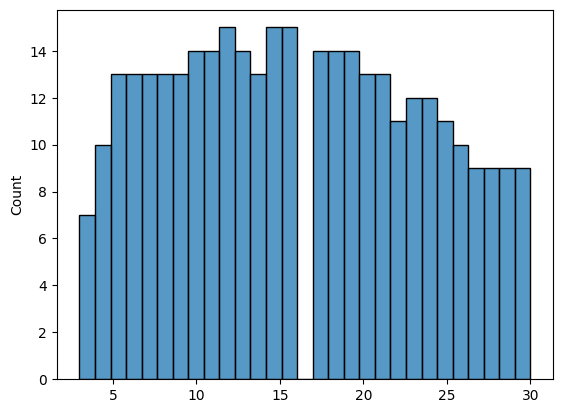

In [32]:
sns.histplot(lengths, bins=29)

# Model

Implement your model. The model should have the RNN architecture (with LSTM or GRU cells), support stacking and bidirectional feature extraction.

In [33]:
def get_name(
    prefix: str | None = None, suffix: str | None = None, separator: str = "_"
) -> str | None:
    if prefix and suffix:
        return prefix + separator + suffix
    return prefix or suffix or None

In [34]:
def get_model(
    units: int,
    n_tokens: int,
    n_labels: int,
    n_stacks: int = 1,
    bidirectional: bool = False,
    name: str | None = None,
    rnn_type: type[keras.layers.Layer] = keras.layers.LSTM
) -> keras.Model:
    """Creates a model with RNN architecture for sequence multilabel classification.

    Arguments:
        units: dimensionality of RNN cells
        n_tokens: number of tokens in the tokenizer dictionary
        n_labels: number of labels to be predicted
        n_stacks: number of RNN cells in the stack (1 -- no stacking)
        bidirectional: whether or not the model is bidirectional
        name: the model name
        rnn_type: type of a rnn to use, either keras.layers.LSTM or keras.layers.GRU

    Returns:
        The model"""

    def build_rnn(x: keras.layers.Layer) -> keras.layers.Layer:
        for i in range(n_stacks):
            is_last = i == n_stacks - 1

            rnn = rnn_type(units=units, return_sequences=not is_last)

            if bidirectional:
                x = keras.layers.Bidirectional(rnn)(x)
            else:
                x = rnn(x)

        return x

    inputs = keras.Input(shape=(None,), dtype="int32")
    x = keras.layers.Embedding(n_tokens, 64)(inputs)

    x = build_rnn(x)

    x = keras.layers.Dropout(0.5)(x)
    x = keras.layers.Dense(128, activation="relu")(x)
    x = keras.layers.Dropout(0.3)(x)
    x = keras.layers.Dense(n_labels, activation="sigmoid")(x)

    return keras.models.Model(inputs=inputs, outputs=x, name=name)


In [35]:
from pathlib import Path

MODEL_CHECKPOINT_DIR = Path("../../model_checkpoints/rnn_sequence_classification2")
LOGS_DIR = Path("../../logs/rnn_sequence_classification2")

# Training

Train several models on the two dataset variants. Use either of the cell types (LSTM or GRU)
* Simple RNN (no stacking, one direction)
* Stacked RNN (stacking, one direction)
* Bidirectional RNN (no stacking, bidirectional)
* Stacked Bidirectional RNN (stacking, bidirectional)

In [163]:
model_configs = [
    {
        "units": 64,
        "name": "Simple RNN",
        "bidirectional": False,
        "n_stacks": 1,
        "rnn_type": keras.layers.LSTM,
    },
    {
        "units": 64,
        "name": "Stacked RNN",
        "bidirectional": False,
        "n_stacks": 2,
        "rnn_type": keras.layers.LSTM,
    },
    {
        "units": 64,
        "name": "Bidirectional RNN",
        "bidirectional": True,
        "n_stacks": 1,
        "rnn_type": keras.layers.LSTM,
    },
    {
        "units": 64,
        "name": "Stacked Bidirectional RNN",
        "bidirectional": True,
        "n_stacks": 2,
        "rnn_type": keras.layers.LSTM,
    },
]

In [164]:
models = [
    get_model(
        units=config["units"],
        n_tokens=len(tokenizer.get_vocab()),
        n_labels=len(emotions),
        name=config["name"],
        bidirectional=config["bidirectional"],
        n_stacks=config["n_stacks"],
        rnn_type=config["rnn_type"],
    )
    for config in model_configs
]

Which loss should be used to multilabel classification? Which metrics?

In [165]:
for model in models:
    model.compile(
        loss=keras.losses.BinaryFocalCrossentropy(
            alpha=0.25,
            gamma=2.0,
        ),
        optimizer=keras.optimizers.AdamW(1e-3),
        metrics=[
            keras.metrics.AUC(name="auc", multi_label=True),
            keras.metrics.F1Score(name="f1_macro", average="macro", threshold=0.5),
            keras.metrics.F1Score(name="f1_micro", average="micro", threshold=0.5),
        ],
    )

In [100]:
import gc


class Stabilizer(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

In [101]:
from torch.utils.tensorboard import SummaryWriter


class PyTorchTensorBoard(keras.callbacks.Callback):
    def __init__(self, log_dir):
        super().__init__()
        self.writer = SummaryWriter(log_dir)

    def on_epoch_end(self, epoch, logs=None):
        if logs:
            for key, value in logs.items():
                self.writer.add_scalar(key, value, epoch)

In [102]:
from datetime import UTC, datetime


def get_callbacks(model_name: str) -> list[keras.callbacks.Callback]:
    return [
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_auc",
            mode="max",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=3,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            MODEL_CHECKPOINT_DIR / f"{model_name}_auc.keras",
            monitor="val_auc",
            mode="max",
            save_best_only=True,
        ),
        keras.callbacks.ModelCheckpoint(
            MODEL_CHECKPOINT_DIR / f"{model_name}_f1_macro.keras",
            monitor="val_f1_macro",
            mode="max",
            save_best_only=True,
        ),
        Stabilizer(),
        PyTorchTensorBoard(
            LOGS_DIR / f"{model_name}-{datetime.now(tz=UTC).strftime('%Y%m%d-%H%M%S')}"
        ),
    ]

In [169]:
for ds_train, ds_test, ds_type in [
    (ds_fixed_train, ds_fixed_test, "fixed_lengths"),
    (ds_variable_train, ds_variable_test, "variable_lengths"),
]:
    for model in models:
        model.fit(ds_train, validation_data=ds_test, epochs=30, callbacks=get_callbacks(f"{model.name} {ds_type}"))

Epoch 1/30


c:\Users\Yanovich\Documents\Projects\Cats\neural\.venv\Lib\site-packages\keras\src\backend\torch\rnn.py:651: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  outputs, (h_n, c_n) = torch._VF.lstm(


342/342 ━━━━━━━━━━━━━━━━━━━━ 59s 174ms/step - auc: 0.5128 - f1_macro: 0.0375 - f1_micro: 0.2183 - loss: 0.0845 - val_auc: 0.5780 - val_f1_macro: 0.0251 - val_f1_micro: 0.2844 - val_loss: 0.0769 - learning_rate: 0.0010
Epoch 2/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 58s 170ms/step - auc: 0.6076 - f1_macro: 0.0289 - f1_micro: 0.2488 - loss: 0.0759 - val_auc: 0.6887 - val_f1_macro: 0.0460 - val_f1_micro: 0.2777 - val_loss: 0.0709 - learning_rate: 0.0010
Epoch 3/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 58s 171ms/step - auc: 0.7157 - f1_macro: 0.0666 - f1_micro: 0.2841 - loss: 0.0699 - val_auc: 0.7264 - val_f1_macro: 0.0848 - val_f1_micro: 0.3088 - val_loss: 0.0684 - learning_rate: 0.0010
Epoch 4/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 58s 170ms/step - auc: 0.7636 - f1_macro: 0.0978 - f1_micro: 0.3117 - loss: 0.0662 - val_auc: 0.7495 - val_f1_macro: 0.1256 - val_f1_micro: 0.3421 - val_loss: 0.0668 - learning_rate: 0.0010
Epoch 5/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 58s 170ms/step - auc: 0.7969 - f1_macro: 0.1178 - f1_mi

# Evaluation

Evaluate the models you trained on the test datasets. Plot ROC curves for each label (use `sklearn.metrics.RocCurveDisplay`) for each model.

In [63]:
def plot_roc_curve(
    dataset: GoEmotionsDataset, model: keras.Model, dataset_type: str, ax: plt.Axes | None = None
) -> float:
    """Plots ROC curves for each of the labels (on a single axes) and outputs mean ROC AUC score.

    Arguments:
        X: model inputs
        y: ground thruths
        model: model to plot the curve for
        ax: axes to plot on

    Returns:
        Mean ROC AUC score"""

    if ax is None:
        _, ax = plt.subplots(figsize=(10, 8))

    y_pred_raw = []
    y_true_raw = []

    for batch in dataset:
        y_pred_raw.append(model.predict(batch[0], verbose=0))
        y_true_raw.append(batch[1])

    y_pred = np.concatenate(y_pred_raw, axis=0)
    y_true = np.concatenate(y_true_raw, axis=0)

    aucs: list[float] = []
    for i, emotion in enumerate(emotions):
        display = sklearn.metrics.RocCurveDisplay.from_predictions(
            y_true[:, i],
            y_pred[:, i],
            ax=ax,
            name=emotion,
        )
        aucs.append(display.roc_auc)

    mean_auc = float(np.mean(aucs))

    ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="chance")

    ax.set_title(f"{model.name} {dataset_type}: ROC per emotion for model (mean AUC = {mean_auc:.4f})")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right", fontsize="small", ncol=2)

    return mean_auc

In [64]:
models_roc = {"fixed": [], "variable": []}
models_f1 = {"fixed": [], "variable": []}

for file in MODEL_CHECKPOINT_DIR.iterdir():
    if file.is_dir():
        continue

    model = keras.models.load_model(file)

    ds_type = "fixed" if "fixed" in file.name else "variable"

    if "auc" in file.name:
        models_roc[ds_type].append((file.name, model))
    else:
        models_f1[ds_type].append((file.name, model))

In [65]:
for filename, model in models_roc["fixed"]:
    print(filename)

Bidirectional RNN fixed_lengths_auc.keras
Simple RNN fixed_lengths_auc.keras
Stacked Bidirectional RNN fixed_lengths_auc.keras
Stacked RNN fixed_lengths_auc.keras


Plot the mean ROC AUC scores. Which model has the highest score? On what kind of dataset?

c:\Users\Yanovich\Documents\Projects\Cats\neural\.venv\Lib\site-packages\keras\src\backend\torch\rnn.py:651: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  outputs, (h_n, c_n) = torch._VF.lstm(


Mean ROC AUC: 0.8010


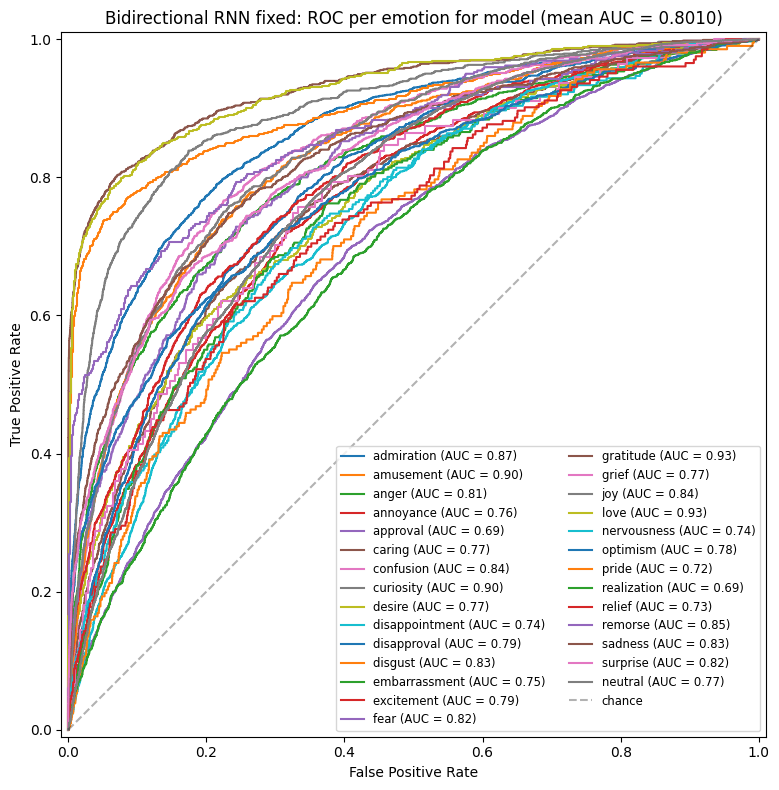

c:\Users\Yanovich\Documents\Projects\Cats\neural\.venv\Lib\site-packages\keras\src\backend\torch\rnn.py:651: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  outputs, (h_n, c_n) = torch._VF.lstm(


Mean ROC AUC: 0.7675


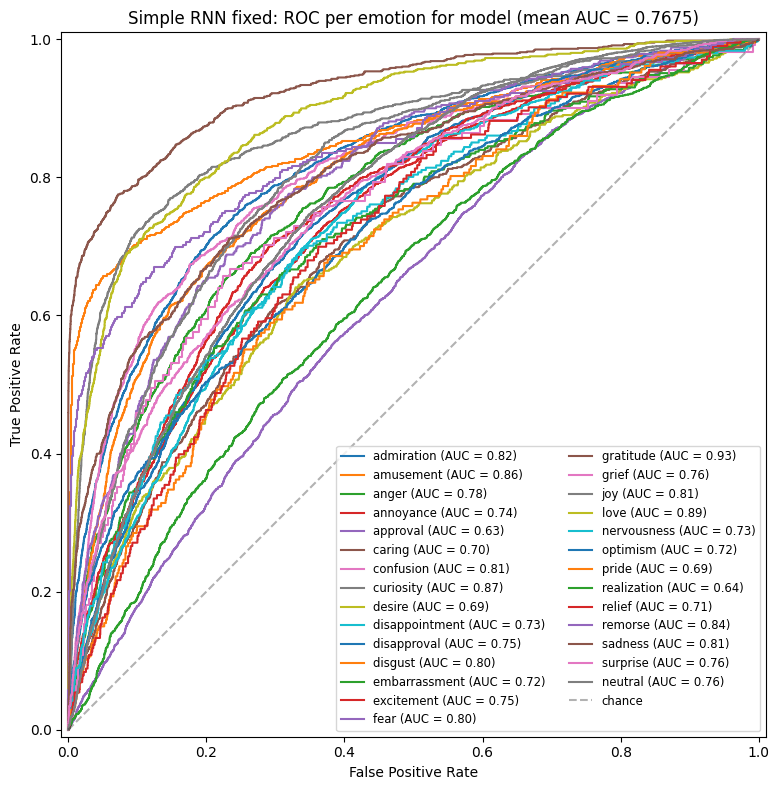

c:\Users\Yanovich\Documents\Projects\Cats\neural\.venv\Lib\site-packages\keras\src\backend\torch\rnn.py:651: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  outputs, (h_n, c_n) = torch._VF.lstm(


Mean ROC AUC: 0.7967


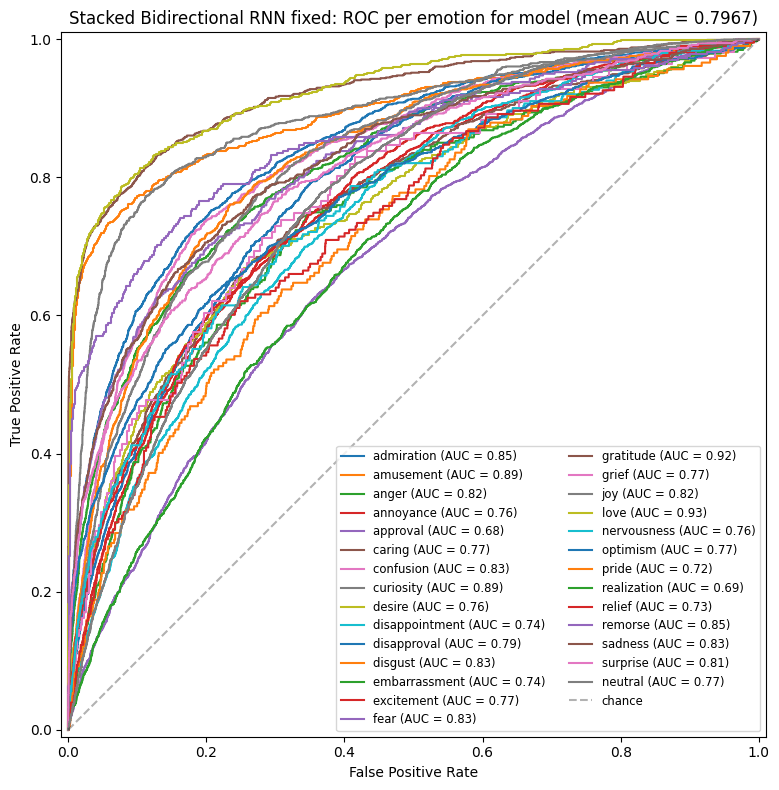

c:\Users\Yanovich\Documents\Projects\Cats\neural\.venv\Lib\site-packages\keras\src\backend\torch\rnn.py:651: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  outputs, (h_n, c_n) = torch._VF.lstm(


Mean ROC AUC: 0.7768


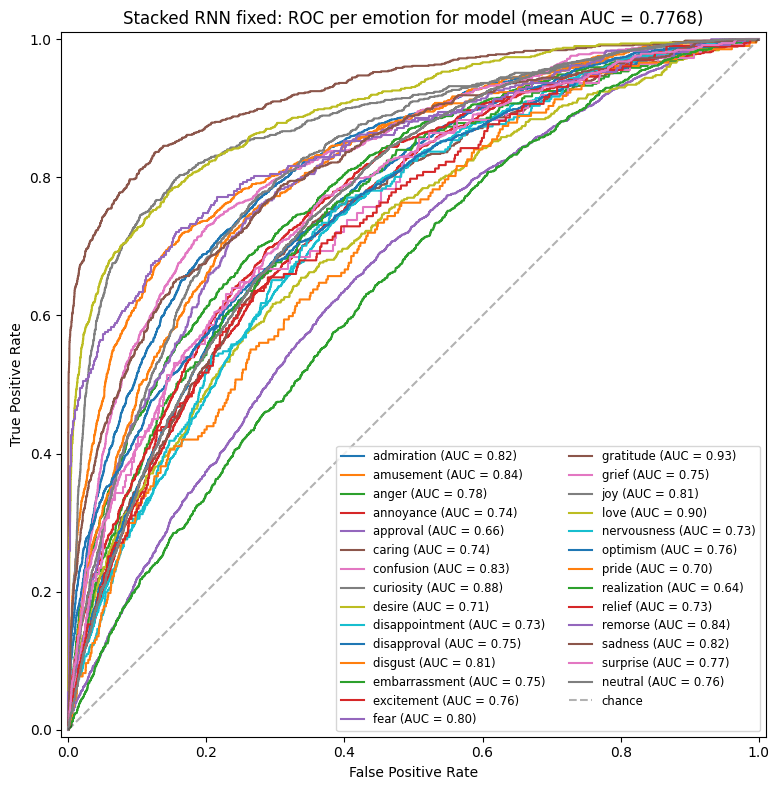

c:\Users\Yanovich\Documents\Projects\Cats\neural\.venv\Lib\site-packages\keras\src\backend\torch\rnn.py:651: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  outputs, (h_n, c_n) = torch._VF.lstm(


Mean ROC AUC: 0.7992


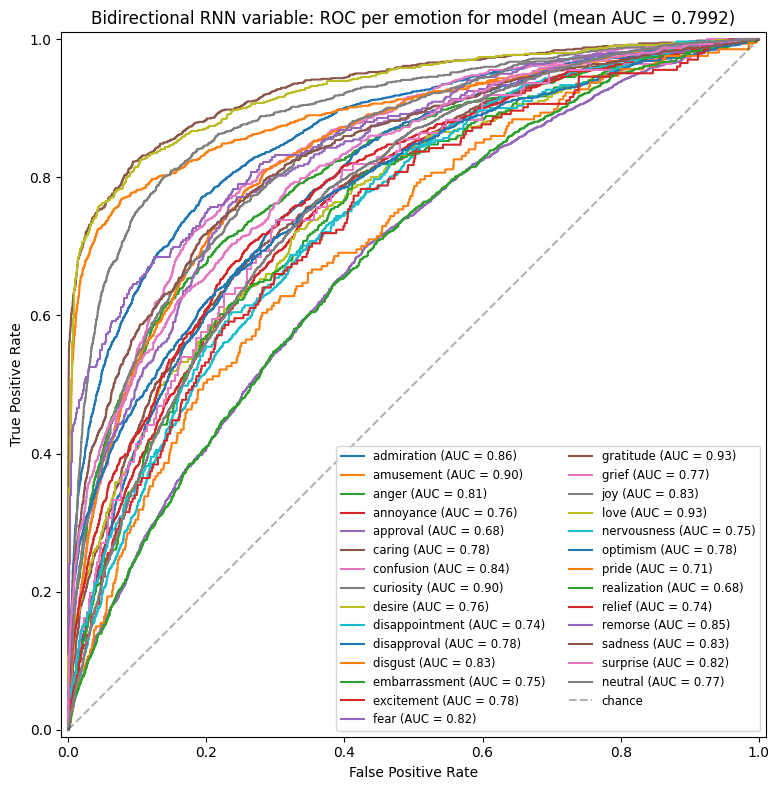

c:\Users\Yanovich\Documents\Projects\Cats\neural\.venv\Lib\site-packages\keras\src\backend\torch\rnn.py:651: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  outputs, (h_n, c_n) = torch._VF.lstm(


Mean ROC AUC: 0.7594


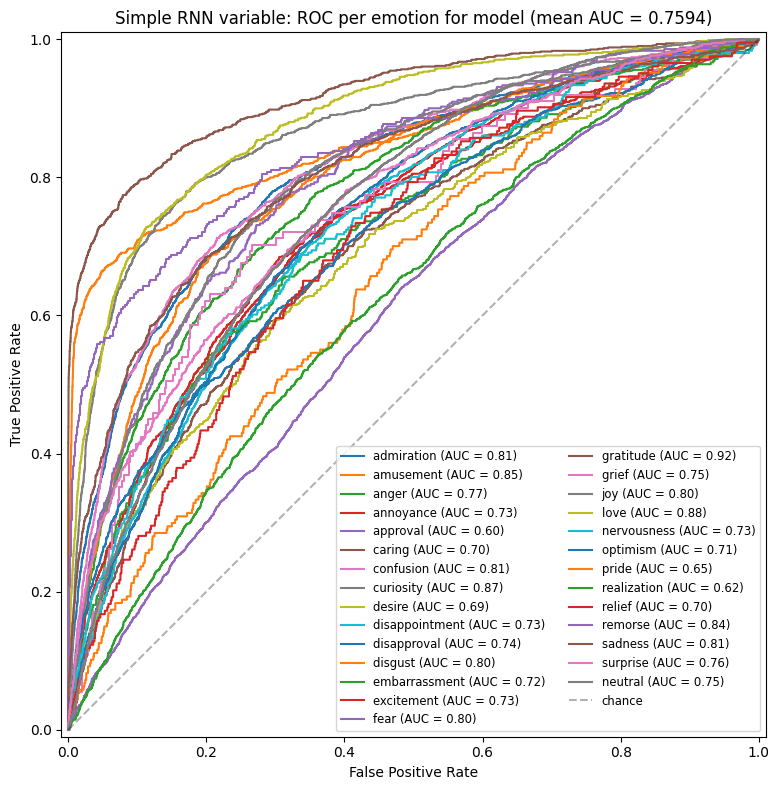

c:\Users\Yanovich\Documents\Projects\Cats\neural\.venv\Lib\site-packages\keras\src\backend\torch\rnn.py:651: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  outputs, (h_n, c_n) = torch._VF.lstm(


Mean ROC AUC: 0.7918


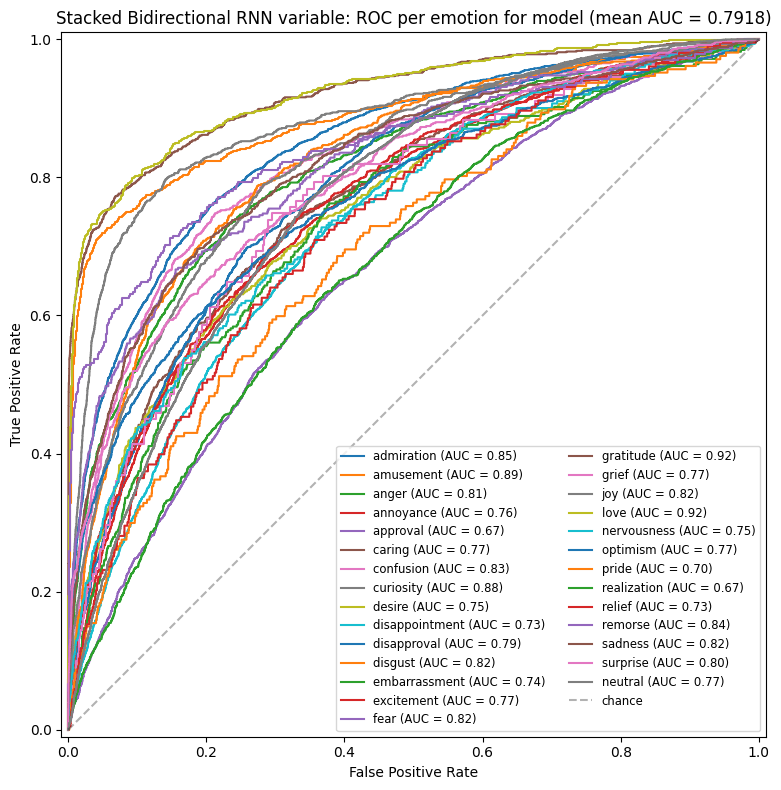

c:\Users\Yanovich\Documents\Projects\Cats\neural\.venv\Lib\site-packages\keras\src\backend\torch\rnn.py:651: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  outputs, (h_n, c_n) = torch._VF.lstm(


Mean ROC AUC: 0.7683


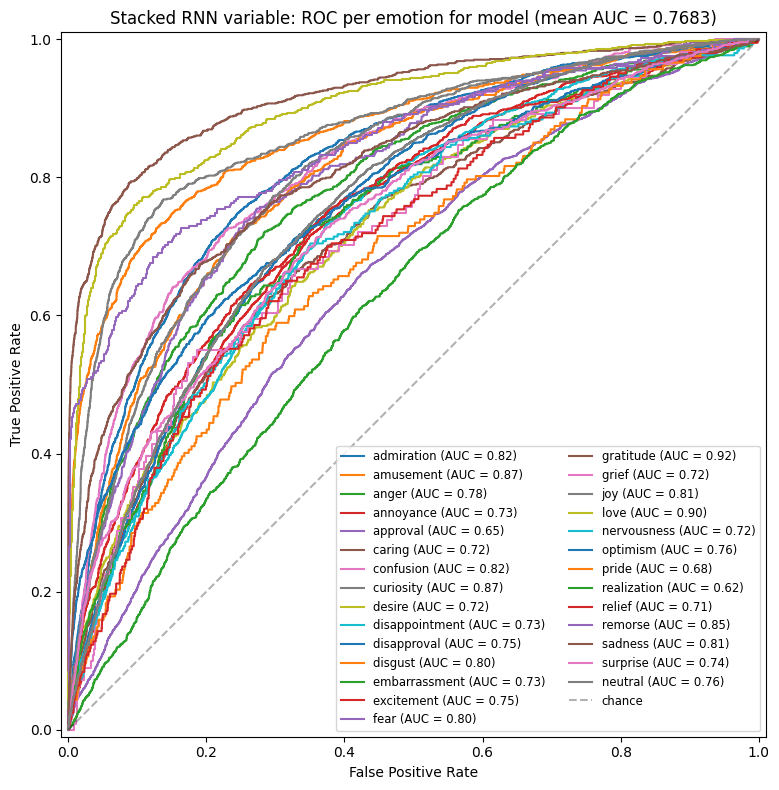

In [81]:
model_scores = []

for ds_type, dataset in models_roc.items():
    for _, model in dataset:
        fig, ax = plt.subplots(figsize=(10, 8))
        mean_auc = plot_roc_curve(ds_fixed_test, model, ds_type, ax=ax)
        model_scores.append(
            {"Model": model.name, "ROC AUC": mean_auc, "DS Type": ds_type}
        )
        print(f"Mean ROC AUC: {mean_auc:.4f}")
        plt.tight_layout()
        plt.show()

In [83]:
score_df = pd.DataFrame(model_scores)
score_df_sorted = score_df.sort_values(by='ROC AUC', ascending=False)

Text(0.5, 1.0, 'Models Mean ROC AUC by Dataset type')

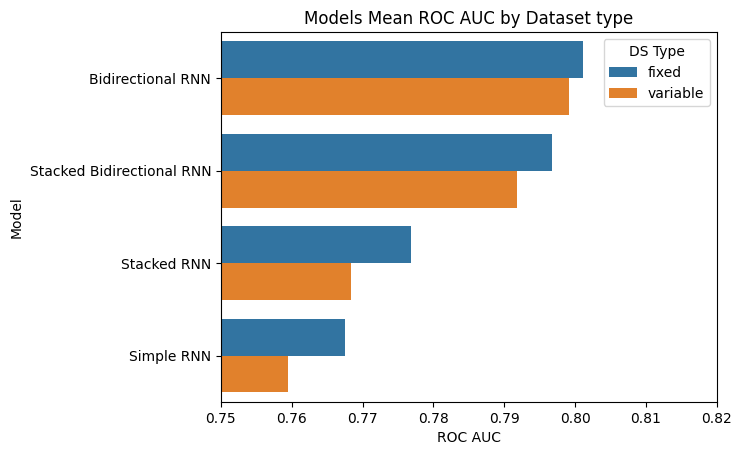

In [87]:
ax = sns.barplot(x="ROC AUC", y="Model", data=score_df_sorted, hue="DS Type", orient="h")
ax.set_xlim(0.75, 0.82)
ax.set_title("Models Mean ROC AUC by Dataset type")

Inspect the best model performance closer. Come up with some sentences (in English). Does the model output sensible results?

In [104]:
def tokenize_text(text: str, max_length: int | None = None) -> np.ndarray:
    tokens = tokenizer.encode(text)
    tokens = keras.utils.pad_sequences(
        [tokens], maxlen=max_length, padding="post", truncating="post", value=tokenizer.eos_token_id
    )
    return tokens

In [105]:
def label_text(
    text: str, model: keras.Model, threshold: float = 0.5, max_length: int | None = None
) -> list[str]:
    """Computes the model output for `text` and outputs a list of emotions that have a probability of at least `threshold`

    Arguments:
        text: text to label
        model: model to use
        threshold: threshold to use
        max_length: max length for tokenization

    Return:
        List of predicted emotion labels"""

    tokens = tokenize_text(text, max_length)

    prediction = model.predict(tokens, verbose=0)

    output = []

    for probs in prediction:
        for prob, emotion in zip(probs, emotions):
            if prob > threshold:
                output.append(emotion)

    return output

In [106]:
import textwrap

In [107]:
def plot_emotion_scores(
    text: str,
    model: keras.Model,
    max_length: int | None = None,
    ax: plt.Axes | None = None,
):
    """Plots a bar plot of emotion probabilities for given `text` using `model`.

    Arguments:
        text: text to label
        model: model to use
        max_length: max length for tokenization
        ax: axes to plot on"""
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 6))

    tokens = tokenize_text(text, max_length)

    prediction = model.predict(tokens, verbose=0)

    sns.barplot(x=prediction[0], y=emotions, ax=ax, orient="h")
    plt.title(f"{model.name}: Emotions probabilities")

    text = "\n".join(textwrap.wrap(text, 20))
    ax.text(
        0.98,
        0.98,
        text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        family='monospace',
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.5},
    )
    ax.set_xlim(left=None, right=max(prediction[0]) * 1.4)

For each of your texts get a list of emotion labels and plot emotion scores

In [108]:
texts = ["I like pizza", "I dont like pizza", "I hate pizza", "I don't dislike pizza"]

c:\Users\Yanovich\Documents\Projects\Cats\neural\.venv\Lib\site-packages\keras\src\backend\torch\rnn.py:651: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  outputs, (h_n, c_n) = torch._VF.lstm(
c:\Users\Yanovich\Documents\Projects\Cats\neural\.venv\Lib\site-packages\keras\src\backend\torch\rnn.py:651: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  outputs, (h_n, c_n) = torch._VF.lstm(
c:\Users\Yanov

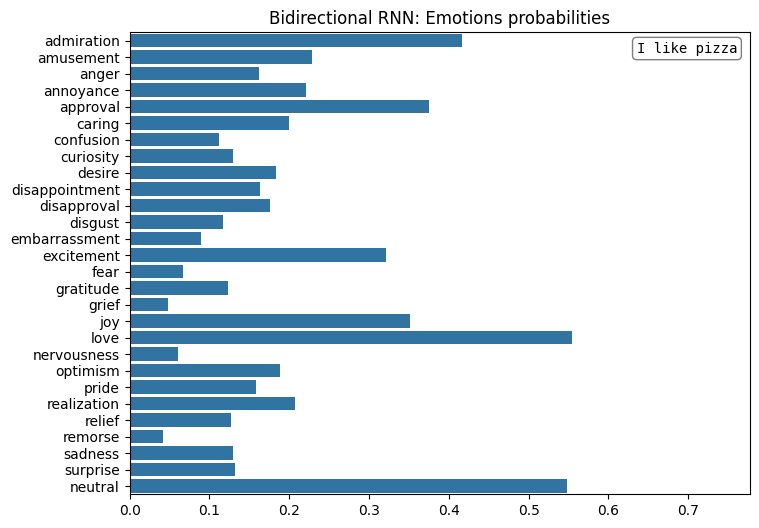

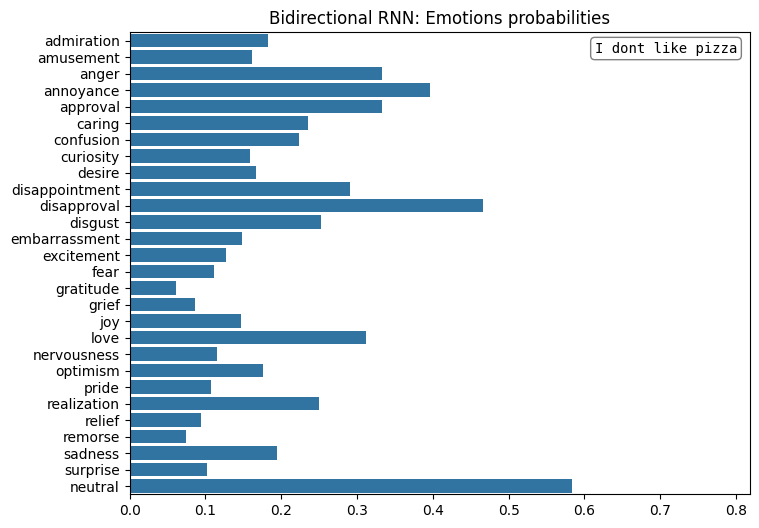

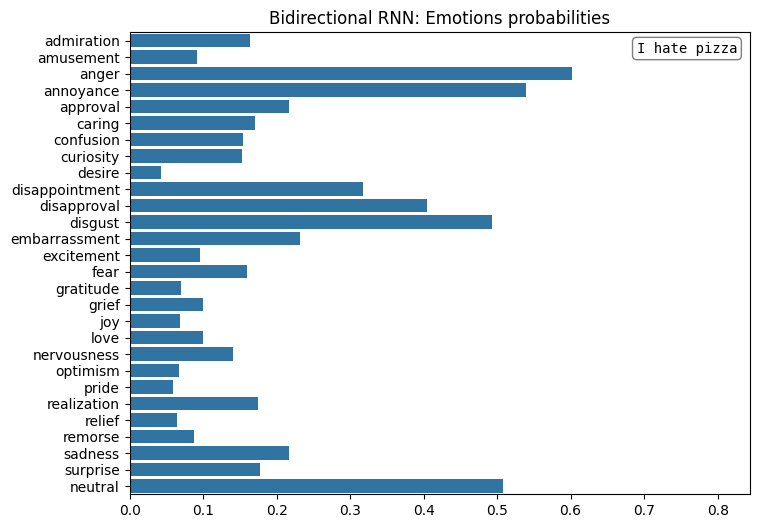

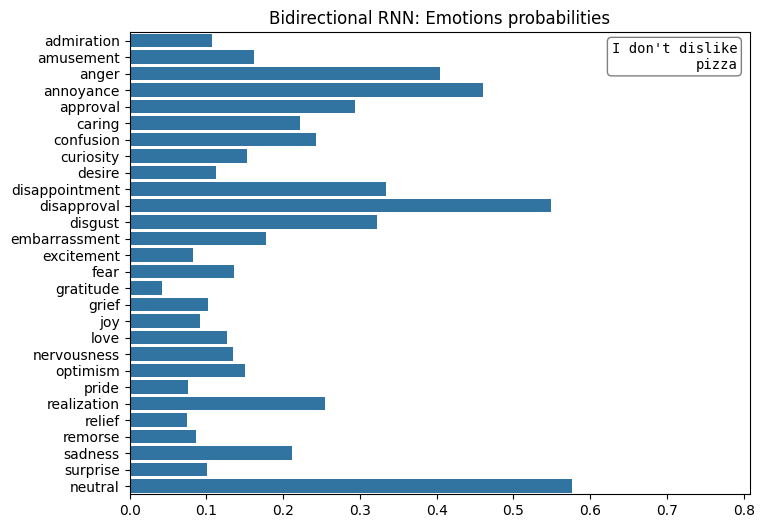

In [109]:
for text in texts:
    plot_emotion_scores(text, models_roc["fixed"][0][1], 31)

# Bonus

Train and evaluate the same model as your best one, but use a different cell type

In [96]:
bonus_model_config = {
    "units": 64,
    "name": "Bidirectional RNN GRU",
    "bidirectional": True,
    "n_stacks": 1,
    "cell_type": keras.layers.GRU
}

In [97]:
bonus_model = get_model(
    units=bonus_model_config["units"],
    n_tokens=len(tokenizer.get_vocab()) + 1,
    n_labels=len(emotions),
    name=bonus_model_config["name"],
    bidirectional=bonus_model_config["bidirectional"],
    n_stacks=bonus_model_config["n_stacks"]
)

In [98]:
bonus_model.compile(
    loss=keras.losses.BinaryFocalCrossentropy(
        alpha=0.25,
        gamma=2.0,
    ),
    optimizer=keras.optimizers.AdamW(1e-3),
    metrics=[
        keras.metrics.AUC(name="auc", multi_label=True),
        keras.metrics.F1Score(name="f1_macro", average="macro", threshold=0.5),
        keras.metrics.F1Score(name="f1_micro", average="micro", threshold=0.5),
    ],
)

In [103]:
bonus_model.fit(
    ds_fixed_train,
    validation_data=ds_fixed_test,
    epochs=30,
    callbacks=get_callbacks(bonus_model.name),
)

Epoch 1/30


c:\Users\Yanovich\Documents\Projects\Cats\neural\.venv\Lib\site-packages\keras\src\backend\torch\rnn.py:651: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  outputs, (h_n, c_n) = torch._VF.lstm(


342/342 ━━━━━━━━━━━━━━━━━━━━ 81s 236ms/step - auc: 0.5653 - f1_macro: 0.0443 - f1_micro: 0.2223 - loss: 0.0821 - val_auc: 0.7056 - val_f1_macro: 0.0550 - val_f1_micro: 0.2649 - val_loss: 0.0704 - learning_rate: 0.0010
Epoch 2/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 90s 263ms/step - auc: 0.7392 - f1_macro: 0.1106 - f1_micro: 0.3171 - loss: 0.0679 - val_auc: 0.7737 - val_f1_macro: 0.1395 - val_f1_micro: 0.3564 - val_loss: 0.0642 - learning_rate: 0.0010
Epoch 3/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 91s 267ms/step - auc: 0.8069 - f1_macro: 0.1786 - f1_micro: 0.3746 - loss: 0.0618 - val_auc: 0.7923 - val_f1_macro: 0.2066 - val_f1_micro: 0.3978 - val_loss: 0.0622 - learning_rate: 0.0010
Epoch 4/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 83s 242ms/step - auc: 0.8413 - f1_macro: 0.2380 - f1_micro: 0.4270 - loss: 0.0577 - val_auc: 0.7965 - val_f1_macro: 0.2536 - val_f1_micro: 0.4330 - val_loss: 0.0618 - learning_rate: 0.0010
Epoch 5/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 85s 250ms/step - auc: 0.8635 - f1_macro: 0.2775 - f1_mi

c:\Users\Yanovich\Documents\Projects\Cats\neural\.venv\Lib\site-packages\keras\src\backend\torch\rnn.py:651: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  outputs, (h_n, c_n) = torch._VF.lstm(


Mean ROC AUC: 0.7994


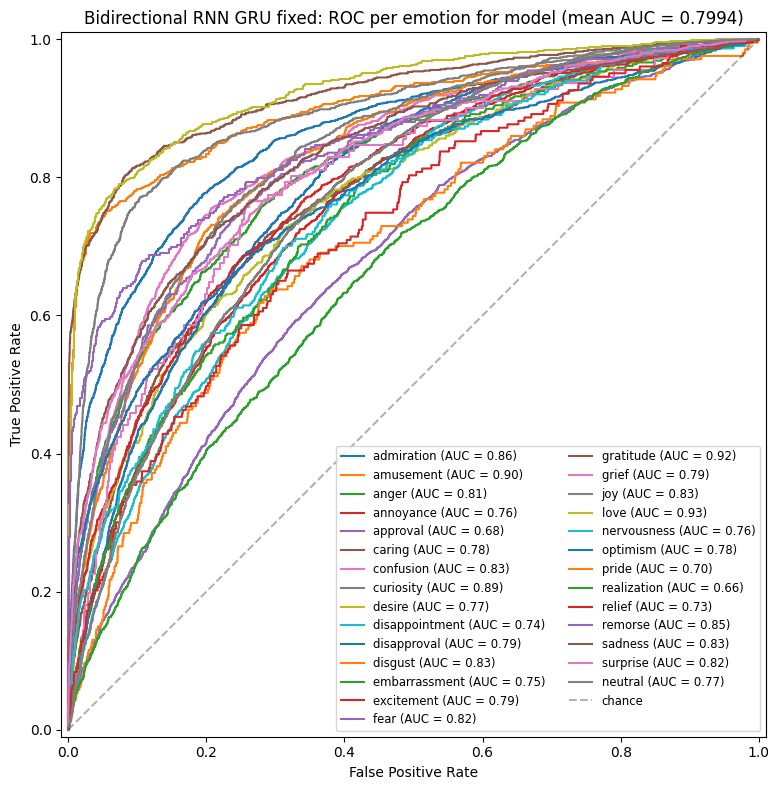

In [110]:
fig, ax = plt.subplots(figsize=(10, 8))
mean_auc = plot_roc_curve(ds_fixed_test, bonus_model, "fixed", ax=ax)
model_scores.append(
    {"Model": bonus_model.name, "ROC AUC": mean_auc, "DS Type": "fixed"}
)
print(f"Mean ROC AUC: {mean_auc:.4f}")
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Models Mean ROC AUC by Dataset type')

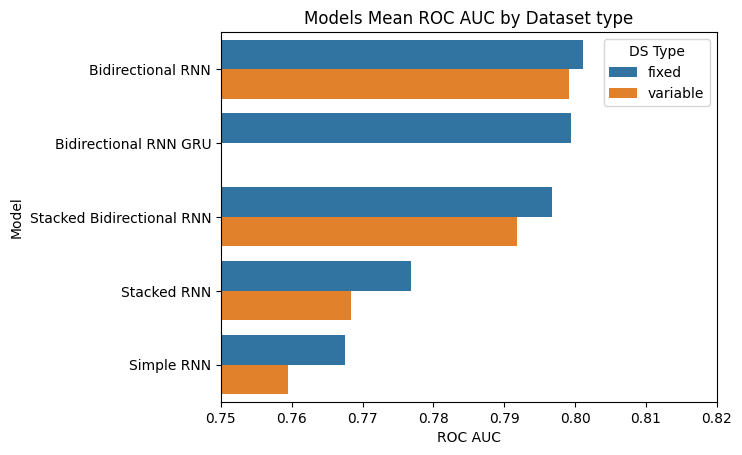

In [111]:
score_df = pd.DataFrame(model_scores)
score_df_sorted = score_df.sort_values(by='ROC AUC', ascending=False)

ax = sns.barplot(x="ROC AUC", y="Model", data=score_df_sorted, hue="DS Type", orient="h")
ax.set_xlim(0.75, 0.82)
ax.set_title("Models Mean ROC AUC by Dataset type")